# Storm Path Visualization (6h, 12h, 18h, 24h)
This notebook visualizes the actual vs predicted storm paths for 6h, 12h, 18h, and 24h horizons.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [27]:
# Data and Model Paths
DATA_PATH = r'c:\Users\ADMIN\Documents\Storm path predictor\Datasets\Storm_data\test.csv'
MODEL_DIR = r'c:\Users\ADMIN\Documents\Storm path predictor\src\train\Xgboost\models'

# Load test data
df = pd.read_csv(DATA_PATH, low_memory=False)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(by=['international_id', 'time'])

# Extract a sample storm from test set for visualization
sample_storm_id = df['international_id'].unique()[0]
storm_data = df[df['international_id'] == sample_storm_id].copy()
print(f"Selected Test Storm ID: {sample_storm_id}")


Selected Test Storm ID: 1


In [28]:
# Feature Engineering mapping used in training
storm_data['month'] = storm_data['time'].dt.month
storm_data['day'] = storm_data['time'].dt.day
storm_data['hour'] = storm_data['time'].dt.hour

storm_data['month_sin'] = np.sin(2 * np.pi * storm_data['month'] / 12)
storm_data['month_cos'] = np.cos(2 * np.pi * storm_data['month'] / 12)
storm_data['day_sin'] = np.sin(2 * np.pi * storm_data['day'] / 31)
storm_data['day_cos'] = np.cos(2 * np.pi * storm_data['day'] / 31)
storm_data['hour_sin'] = np.sin(2 * np.pi * storm_data['hour'] / 24)
storm_data['hour_cos'] = np.cos(2 * np.pi * storm_data['hour'] / 24)

# Lag features for position and wind properties (Past values)
lag_props = ['lat', 'lon', 'max_wind_kt', 'dir_50kt', 'rad_50kt_long_nm', 'rad_50kt_short_nm', 
             'dir_30kt', 'rad_30kt_long_nm', 'rad_30kt_short_nm']
lags = {'6h': 1, '12h': 2, '18h': 3, '24h': 4}
for col in lag_props:
    if col in storm_data.columns:
        for l_name, shift_val in lags.items():
            storm_data[f'{col}_lag_{l_name}'] = storm_data[col].shift(shift_val)
            if col in ['lat', 'lon']:
                storm_data[f'past_delta_{col}_{l_name}'] = storm_data[col] - storm_data[f'{col}_lag_{l_name}']

cols_to_drop = ['international_id', 'tc_number', 'name', 'grade_name', 'revision_date', 'year', 'time_diff_hours', 'time', 'month', 'day', 'hour', 'flag_last']
X_features = storm_data.drop(columns=[c for c in cols_to_drop if c in storm_data.columns])
object_cols = X_features.select_dtypes(include=['object']).columns
X_features.drop(columns=object_cols, inplace=True)
X_features = X_features.apply(pd.to_numeric, errors='coerce')


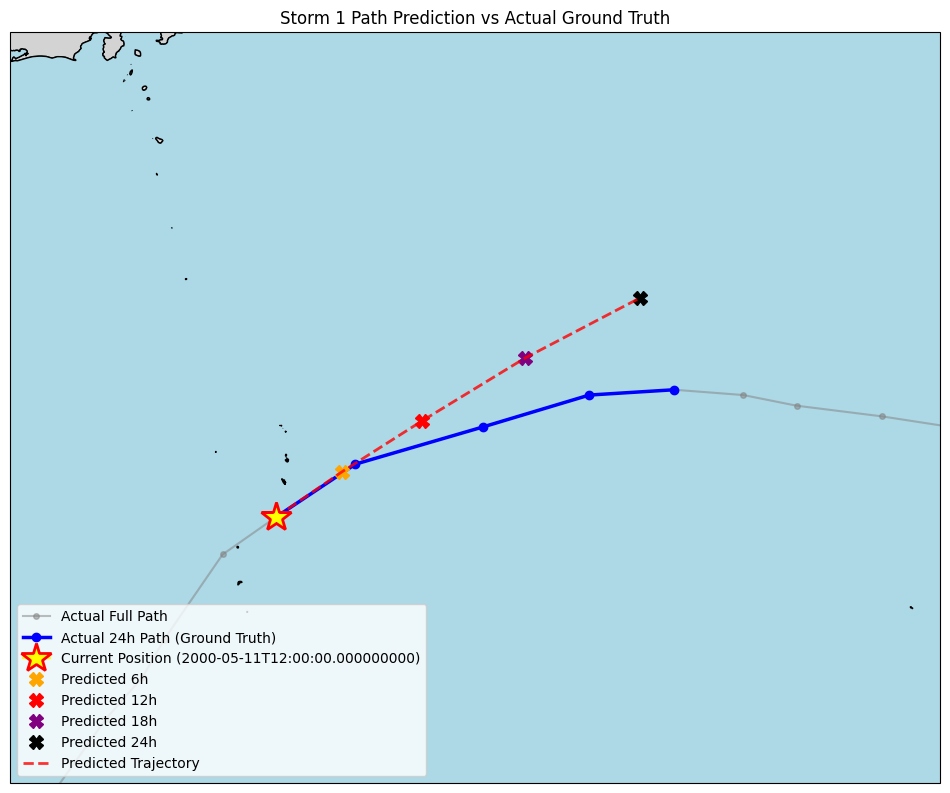

In [35]:
import random

def plot_single_time_predictions(storm_data, X_features):
    if len(storm_data) < 5:
        print("Storm too short to plot predictions.")
        return
        
    # Select a time point with valid past lag features (at least 24h of history)
    valid_indices = [i for i in range(4, len(storm_data) - 4) if not X_features.iloc[i].isna().any()]
    if not valid_indices:
        valid_indices = [i for i in range(len(storm_data) - 4)]
    idx = random.choice(valid_indices)
    
    current_row = storm_data.iloc[[idx]]
    current_features = X_features.iloc[[idx]]
    
    current_lat = current_row['lat'].values[0]
    current_lon = current_row['lon'].values[0]
    current_time = current_row['time'].values[0]
    
    plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    
    # Predict 6h, 12h, 18h, 24h
    colors = {'6h': 'orange', '12h': 'red', '18h': 'purple', '24h': 'black'}
    horizons = ['6h', '12h', '18h', '24h']
    
    pred_lons = [current_lon]
    pred_lats = [current_lat]
    
    for h in horizons:
        model_lat = joblib.load(os.path.join(MODEL_DIR, f'xgboost_delta_lat_{h}.joblib'))
        model_lon = joblib.load(os.path.join(MODEL_DIR, f'xgboost_delta_lon_{h}.joblib'))
        
        pred_delta_lat = model_lat.predict(current_features)[0]
        pred_delta_lon = model_lon.predict(current_features)[0]
        
        pred_lat = current_lat + pred_delta_lat
        pred_lon = current_lon + pred_delta_lon
        
        pred_lats.append(pred_lat)
        pred_lons.append(pred_lon)
        
    # Ground truth future path (next 24h)
    actual_future_lats = [current_lat]
    actual_future_lons = [current_lon]
    for step in range(1, 5):
        if idx + step < len(storm_data):
            actual_future_lats.append(storm_data.iloc[idx + step]['lat'])
            actual_future_lons.append(storm_data.iloc[idx + step]['lon'])

    # Set extent to focus on the prediction zone
    all_lons = pred_lons + actual_future_lons
    all_lats = pred_lats + actual_future_lats
    margin = 5.0  # degrees
    lon_min, lon_max = min(all_lons) - margin, max(all_lons) + margin
    lat_min, lat_max = min(all_lats) - margin, max(all_lats) + margin
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # Plot full storm path
    ax.plot(storm_data['lon'], storm_data['lat'], marker='o', markersize=4, color='gray', alpha=0.5, label='Actual Full Path', transform=ccrs.PlateCarree())
    
    # Plot actual future 24h path (Ground Truth)
    if len(actual_future_lats) > 1:
        ax.plot(actual_future_lons, actual_future_lats, color='blue', linestyle='-', linewidth=2.5, marker='o', markersize=6, label='Actual 24h Path (Ground Truth)', transform=ccrs.PlateCarree(), zorder=3)
    
    # Highlight current position
    ax.plot(current_lon, current_lat, marker='*', markersize=22, color='yellow', markeredgecolor='red', markeredgewidth=2, label=f'Current Position ({current_time})', transform=ccrs.PlateCarree(), zorder=5)
    
    # Plot predicted points and line
    for i, h in enumerate(horizons):
        ax.plot(pred_lons[i+1], pred_lats[i+1], marker='X', markersize=10, color=colors[h], linestyle='None', label=f'Predicted {h}', transform=ccrs.PlateCarree(), zorder=4)
    
    ax.plot(pred_lons, pred_lats, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Predicted Trajectory', transform=ccrs.PlateCarree(), zorder=4)
    
    plt.title(f'Storm {sample_storm_id} Path Prediction vs Actual Ground Truth')
    plt.legend(loc='lower left')
    plt.show()

# Run the visualization
plot_single_time_predictions(storm_data, X_features)
